In [1]:
import pathlib
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import xarray as xr
import importlib
import numpy as np

script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools, interactive

In [34]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)

<module 'dissipationSML.interactive' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/interactive.py'>

## 1. Chose the glider and the mission

In [ ]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', index=6, options=('005', '012', '014', '016', '101', '102', '103', '104…

Dropdown(description='Select Mission:', index=2, options=('02/07 (dives: 679)', '11/07 (dives: 524)', '02/09 (…

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/103/20090223/


In [13]:
### From the chosen glider mission, the important variables are taken. The destination folder is also selected here.
### The mission path gives the exact path to the dedicated mission of the chosen glider. It will be used later to save and load the concatenated/converted data
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

### 1.1 Load the data into a list of .nc files and then convert into OG1 format which is also concatenating the data. 
### The data is saved at the mission path 

In [44]:
### All datasets from the glider mission are downloaded and then loaded as .nc file into one list
datasets = reading.read_basestation(data_path, destination_path=destination_folder, start_profile=1, end_profile=end_profile)


Downloaded: p1030001_20090223.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20090223/p1030001_20090223.nc
Downloaded: p1030002_20090223.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20090223/p1030002_20090223.nc
Downloaded: p1030003_20090223.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20090223/p1030003_20090223.nc
Downloaded: p1030004_20090223.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20090223/p1030004_20090223.nc
Downloaded: p1030005_20090223.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20090223/p1030005_20090223.nc
Downloaded: p1030006_20090224.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20090223/p1030006_20090224.nc
Downloaded: p1030007_20090224.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20090223/p1030007_20090224.nc
Downloaded: p1030008_20090224.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/103/20090223/p1030008_20090224.nc
Downloaded: p1030009_200

In [45]:
variables_needed = ['LONGITUDE','LATITUDE','TIME','DEPTH','GLIDER_VERT_VELO_MODEL','THETA','TEMP',
                    'GLIDE_SPEED','SIGTHETA','SIGMA_T','PSAL','PRES','GLIDER_HORZ_VELO_MODEL','DIVE_NUMBER','PROFILE_NUMBER','PSAL_RAW','TEMP_RAW']
### convert the dataset to OG1 format only with the variables needed
ds = reading.convert_with_variables(datasets,variables_needed)
### calculate potential density from raw data and add it to the dataset
ds = tools.add_pot_density_from_raw_data(ds)

Converting datasets to OG1 format: 100%|██████████| 477/477 [03:43<00:00,  2.13it/s]


In [46]:
### save the OG1 dataset at the destination folder
writers.save_dataset(ds, mission_path + '/all_data_OG1.nc')

True

### 2. Load the dataset and do some plotting

In [14]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')

In [15]:
ds

<xarray.Dataset> Size: 42MB
Dimensions:                 (N_MEASUREMENTS: 404647)
Coordinates:
    LONGITUDE               (N_MEASUREMENTS) float64 3MB ...
    LATITUDE                (N_MEASUREMENTS) float64 3MB ...
    TIME                    (N_MEASUREMENTS) datetime64[ns] 3MB ...
    DEPTH                   (N_MEASUREMENTS) float64 3MB ...
Dimensions without coordinates: N_MEASUREMENTS
Data variables: (12/15)
    GLIDER_VERT_VELO_MODEL  (N_MEASUREMENTS) float32 2MB ...
    THETA                   (N_MEASUREMENTS) float32 2MB ...
    TEMP                    (N_MEASUREMENTS) float32 2MB ...
    GLIDE_SPEED             (N_MEASUREMENTS) float32 2MB ...
    SIGTHETA                (N_MEASUREMENTS) float32 2MB ...
    SIGMA_T                 (N_MEASUREMENTS) float32 2MB ...
    ...                      ...
    DIVE_NUMBER             (N_MEASUREMENTS) int32 2MB ...
    PROFILE_NUMBER          (N_MEASUREMENTS) float64 3MB ...
    PSAL_RAW                (N_MEASUREMENTS) float32 2MB ...
    TEMP_RAW                (N_MEASUREMENTS) float32 2MB ...
    SIGTHETA_RAW            (N_MEASUREMENTS) float64 3MB ...
    SIGMA_T_RAW             (N_MEASUREMENTS) float64 3MB ...
Attributes: (12/39)
    title:                                      OceanGliders trajectory file
    id:                                         sg103_20090223T154007_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    institution:                                School of Oceanography\nUnive...
    ...                                         ...
    license:                                    These data may be redistribut...
    keywords:                                   Water Temperature, Conductivi...
    keywords_vocabulary:                        NASA/GCMD Earth Science Keywo...
    file_version:                               2.71
    disclaimer:                                 Data provided AS-IS.
    acknowledgment:                             National Science Foundation, ...

### 2.1 Plot the glider track and minimum/mximum depth

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:226: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


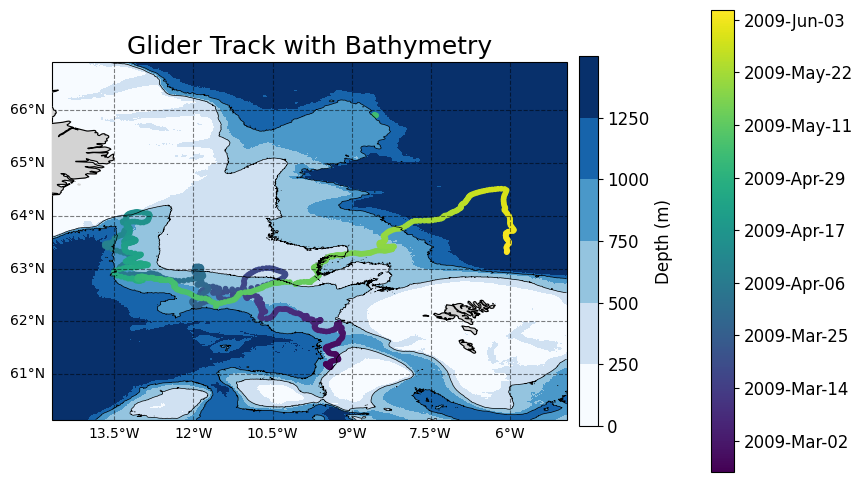

In [17]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds)
display(fig)
### save the figure
#fig.savefig(mission_path + '/glider_track.png', dpi=300)
del fig, ax

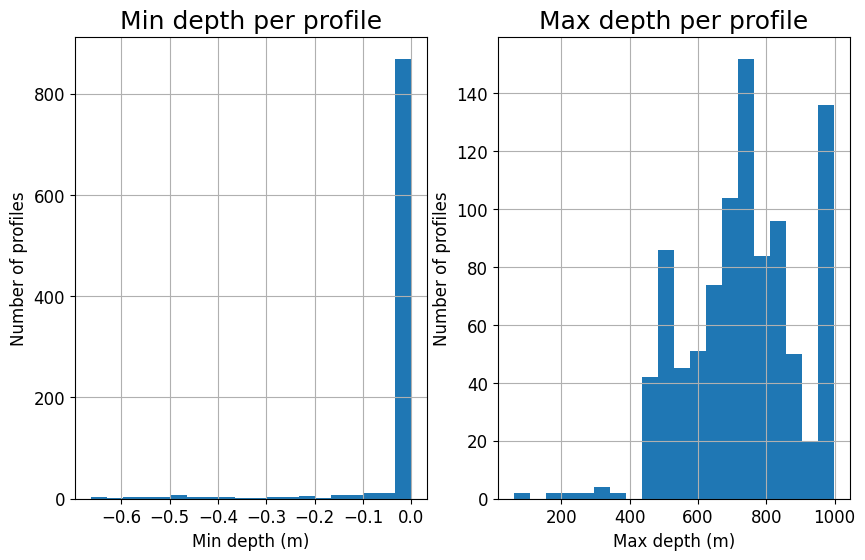

In [20]:
fig, ax = plotting.plot_min_max_depth(ds)
display(fig)
#fig.savefig(mission_path + '/min_max_histogram.png', dpi=300)
del fig, ax


### 2.2 Plot profiles interactively with the possibility of binning

In [21]:
profile_slider = widgets.SelectionSlider(options=np.unique(ds.PROFILE_NUMBER.values).astype(int), description='Profile number:', continuous_update=False)
raw_button = widgets.Checkbox(value=False, description='Raw data')
binning_slider = widgets.IntSlider(value=2, min=1, max=20, description='Binning (m):')
agg_button = widgets.ToggleButtons(options=['mean', 'median'],description='Aggregation:',disabled=False,button_style='')

In [36]:
interactive.interactive_profile(ds, profile_slider, raw_button)

interactive(children=(SelectionSlider(continuous_update=False, description='Profile number:', index=407, optio…

In [37]:
interactive.interactive_resolution_hist(ds, profile_slider)

interactive(children=(SelectionSlider(continuous_update=False, description='Profile number:', index=491, optio…

In [38]:
interactive.interactive_profile_binned(ds, profile_slider, binning_slider, raw_button, agg_button)

interactive(children=(SelectionSlider(continuous_update=False, description='Profile number:', index=491, optio…

### 2.3 Plot the MLD, depending on the settings that were chosen and add it in the next step to the dataset

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:443: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return fig, ax


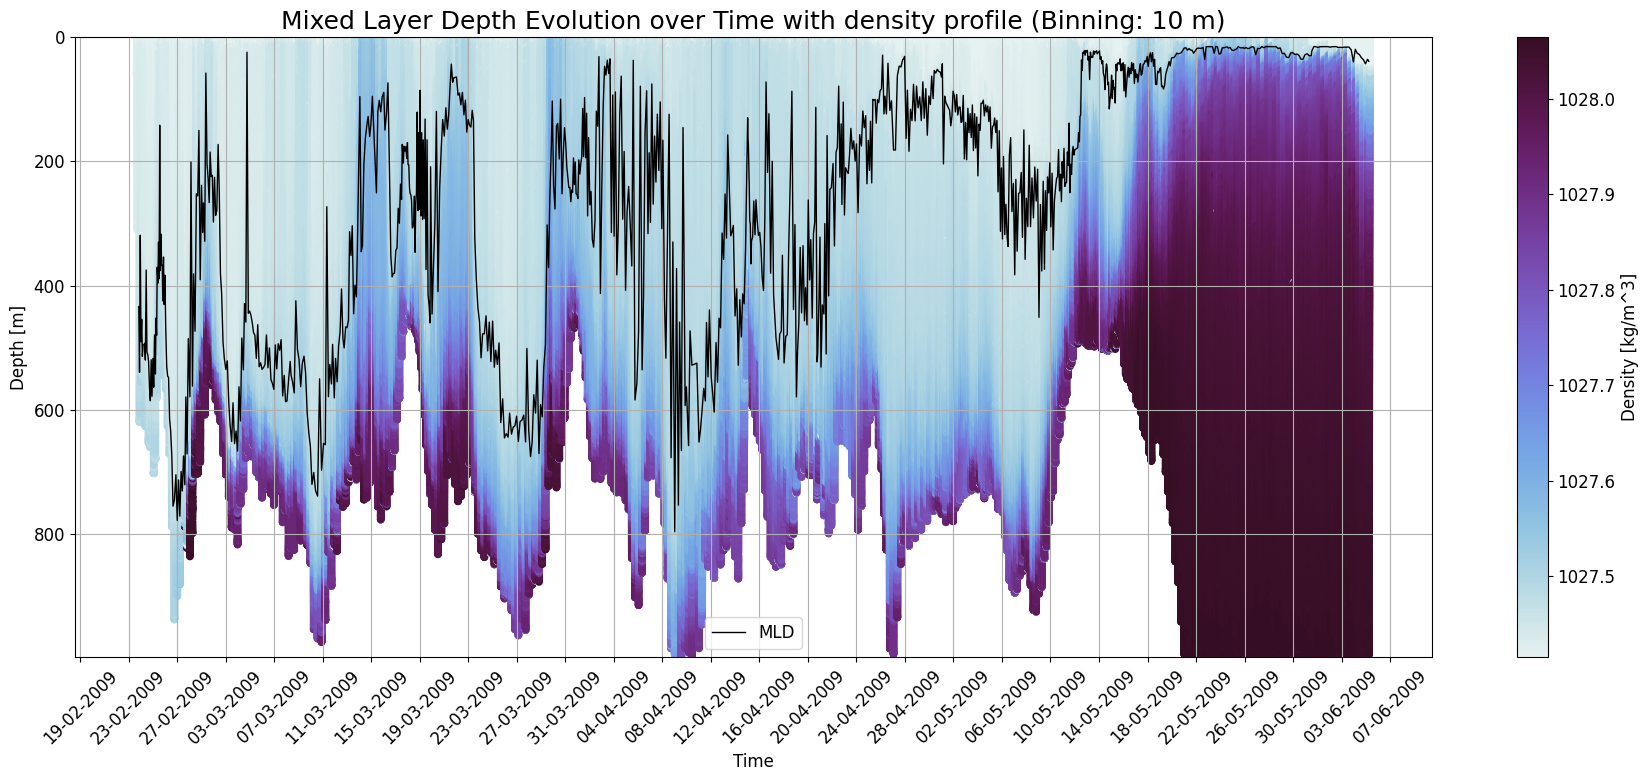

In [50]:
fig,ax = plotting.plot_MLD_evolution(ds,binning = 10,use_raw = False, plot_density= True)
display(fig)
#fig.savefig(mission_path + '/MLD_time_evolution.png', dpi=300)
del fig, ax

In [22]:
### add the MLD to the dataset for each profile
ds = tools.add_MLD_to_dataset(ds, use_bins=True, binning = 10, use_raw = True,agg='median')

Calculating and adding MLD for Profiles:   0%|          | 0/140 [00:00<?, ?profile/s]

Calculating and adding MLD for Profiles: 100%|██████████| 140/140 [00:10<00:00, 13.56profile/s]


In [13]:
# Create sliders for longitude and latitude
default_coords = [[-14.0, 63.5], # First corner
                  [-13, 64.5], # Second corner
                  [-7.5, 62], # Third corner
                  [-9, 61]] # Fourth corner
# Create the interactive selector
get_region = plotting.interactive_region_selector(default_coords)

Button(description='Confirm Selection', style=ButtonStyle())

Output()

Region confirmed!


In [14]:
### get the coordinates of the region and create a new dataset with values only from this region
region = get_region()
ds_region = tools.cut_region(ds, region)

In [15]:
importlib.reload(interactive)
bad_profiles = interactive.interactive_bad_profile_checking(ds_region)

In [48]:
### cutting out profile numbers that are not needed
bad_profiles = np.array(bad_profiles)
ds = ds_region.isel(N_MEASUREMENTS=~np.isin(ds_region.PROFILE_NUMBER.values, bad_profiles))

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


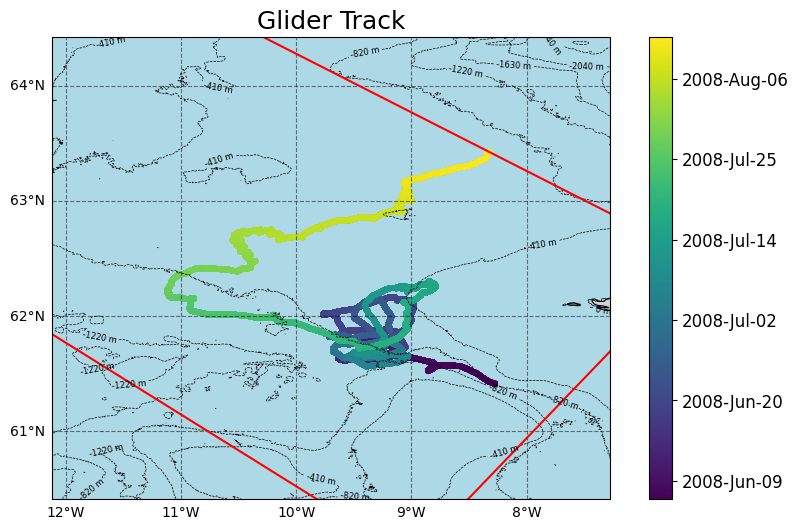

In [20]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds_region)
region.plot(ax=ax, add_label=False, line_kws={'color': 'red'})
display(fig)
#fig.savefig(mission_path + '/glider_track_region.png', dpi=300)
del fig, ax

In [ ]:
### save the dataset with MLD
#writers.save_dataset(ds, mission_path + '/all_data_OG1_with_MLD.nc')